## Library and Evironment

In [ ]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions

## Sources

https://www.nltk.org/install.html


In [2]:
nltk.download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package movie_reviews is already

True

## Pre Processing

In [3]:
def preprocess(text:str | list ) -> list:
    '''
    Function to preprocess the text for N-gram creation.
    - ouputs a list of tokens.
    '''
    try:
        # check the input for dtype. Raise error if not string or list
        if isinstance(text, list):
            text = ' '.join(text)
        elif not isinstance(text, str):
            raise ValueError("Input must be a list or string")
        text = contractions.fix(text) # Expand contractions first
        normalized_tokens_sentences = nltk.sent_tokenize(text)
        normalized_tokens_sentences = [' '.join(re.sub(r'[^a-zA-Z0-9]', '', token.lower()) for token in normalized_tokens_sentences.split())
                                       for normalized_tokens_sentences in normalized_tokens_sentences
                                       ] # normalize sentences
        
        text = [re.sub(r'[^a-zA-Z0-9]', '', token.lower()) for token in text.split()] # normalize
        text = ' '.join(text) # join back into a string for tokenization
        normalized_tokens_words = nltk.word_tokenize(text) # Tokenize into words and sentences for n-gram testing
        return normalized_tokens_words, normalized_tokens_sentences
    except Exception as e:
        print(f"Error in preprocesssing: {e}")
    


In [4]:
sample = [
    "So do all who live to see such times.",
    "But that is not for them to decide.",
    "All we have to decide is what to do with the time that is given us."
]

print(preprocess(sample))


(['so', 'do', 'all', 'who', 'live', 'to', 'see', 'such', 'times', 'but', 'that', 'is', 'not', 'for', 'them', 'to', 'decide', 'all', 'we', 'have', 'to', 'decide', 'is', 'what', 'to', 'do', 'with', 'the', 'time', 'that', 'is', 'given', 'us'], ['so do all who live to see such times', 'but that is not for them to decide', 'all we have to decide is what to do with the time that is given us'])


## N-Grams

In [5]:
# N-grams with word tokenization
bigram = list(nltk.ngrams(preprocess(sample)[0], 2))
trigram = list(nltk.ngrams(preprocess(sample)[0], 3))
fourgram = list(nltk.ngrams(preprocess(sample)[0], 4))
print("Bigrams:", bigram)
print("Trigrams:", trigram)
print("Fourgrams:", fourgram)

Bigrams: [('so', 'do'), ('do', 'all'), ('all', 'who'), ('who', 'live'), ('live', 'to'), ('to', 'see'), ('see', 'such'), ('such', 'times'), ('times', 'but'), ('but', 'that'), ('that', 'is'), ('is', 'not'), ('not', 'for'), ('for', 'them'), ('them', 'to'), ('to', 'decide'), ('decide', 'all'), ('all', 'we'), ('we', 'have'), ('have', 'to'), ('to', 'decide'), ('decide', 'is'), ('is', 'what'), ('what', 'to'), ('to', 'do'), ('do', 'with'), ('with', 'the'), ('the', 'time'), ('time', 'that'), ('that', 'is'), ('is', 'given'), ('given', 'us')]
Trigrams: [('so', 'do', 'all'), ('do', 'all', 'who'), ('all', 'who', 'live'), ('who', 'live', 'to'), ('live', 'to', 'see'), ('to', 'see', 'such'), ('see', 'such', 'times'), ('such', 'times', 'but'), ('times', 'but', 'that'), ('but', 'that', 'is'), ('that', 'is', 'not'), ('is', 'not', 'for'), ('not', 'for', 'them'), ('for', 'them', 'to'), ('them', 'to', 'decide'), ('to', 'decide', 'all'), ('decide', 'all', 'we'), ('all', 'we', 'have'), ('we', 'have', 'to'), (

In [6]:
# N-grams with sentence tokenization
unigram_s = list(nltk.ngrams(preprocess(sample)[1], 1))
bigram_s = list(nltk.ngrams(preprocess(sample)[1], 2))
trigram_s = list(nltk.ngrams(preprocess(sample)[1], 3))
fourgram_s = list(nltk.ngrams(preprocess(sample)[1], 4))
print("Unigram:", unigram_s)
print("Bigrams:", bigram_s)
print("Trigrams:", trigram_s)
print("Fourgrams:", fourgram_s)

Unigram: [('so do all who live to see such times',), ('but that is not for them to decide',), ('all we have to decide is what to do with the time that is given us',)]
Bigrams: [('so do all who live to see such times', 'but that is not for them to decide'), ('but that is not for them to decide', 'all we have to decide is what to do with the time that is given us')]
Trigrams: [('so do all who live to see such times', 'but that is not for them to decide', 'all we have to decide is what to do with the time that is given us')]
Fourgrams: []


## Visualization

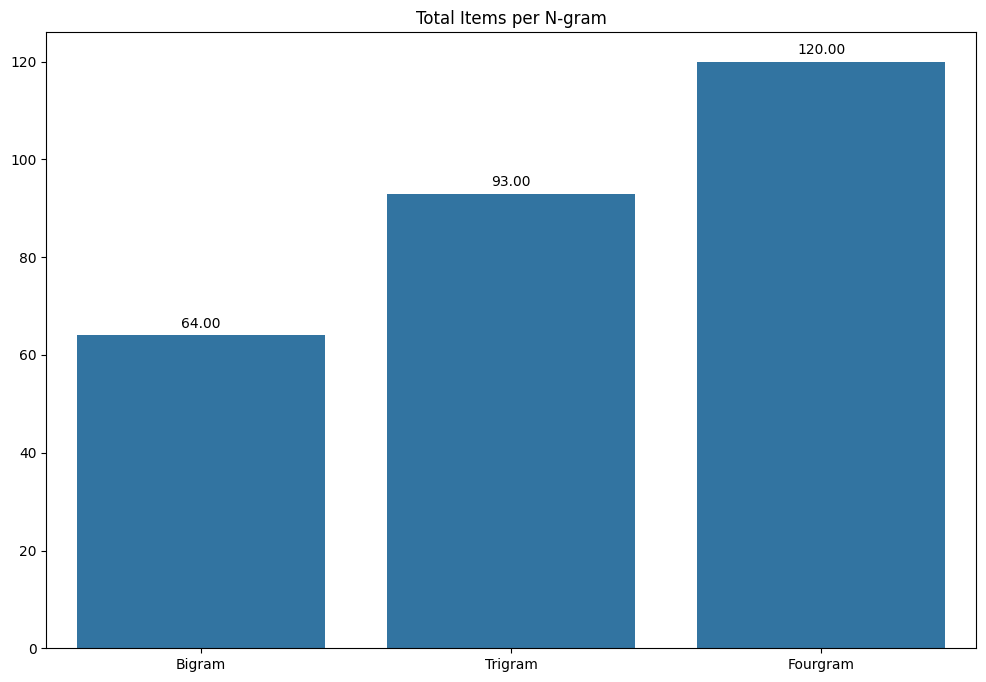

In [31]:
total_bigram = sum(len(i) for i in bigram)
total_trigram = sum(len(i) for i in trigram)
total_fourgram = sum(len(i) for i in fourgram)
plt.figure(figsize=(12,8))
ax = sns.barplot(x=['Bigram', 'Trigram', 'Fourgram'], y=[total_bigram, total_trigram, total_fourgram])
ax.set_title('Total Items per N-gram')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)